##🚚**Inteligência de Mercado e Logística: E-Commerce Olist**

MBA - Data Science & Advanced Analytics

#### **A atividade aborda o tema Análise Exploratória e Resultados Estatísticos.**

O aluno deverá selecionar uma base de dados de sua preferência e, a partir dos subtópicos do tema, realizar interpretações baseadas no conteúdo aprendido em aula.
Resultados das estatísticas exploratória dos dados.

Nessa atividade, o aluno deverá demonstrar a capacidade de interpretar os conceitos abordados.  
O link e o notebook no Google Colab estão disponíveis para consulta e utilização.

#### **Base de dados utilizada:**

A base de dados escolhida para esta atividade é a **Olist - Brazilian E-Commerce Public Dataset**, disponível na plataforma Kaggle.
🔗 https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce  

A base de dados contém informações sobre compras realizadas em uma plataforma de comércio eletrônico brasileira para lojistas chamada Olist, referentes ao período entre 2016 e 2018. Ela é composta por um conjuntos de dados com vários arquivos (.csv) relacionados entre si.   
Para a análise serão utilizados principalmente os arquivos: clientes, pedidos e itens dos pedidos, que possuem as informações relacionadas aos pedidos, valores monetários das compras e à localização geográfica dos consumidores.  
O objetivo desta análise é realizar uma estatística exploratória dos dados, conforme os conceitos abordados na aula.

In [1]:
import pandas as pd

# Importacao dos dados 

# Caminho dos CSVs (mesma pasta do notebook)
customers = pd.read_csv("base_Olist/olist_customers_dataset.csv")
orders = pd.read_csv("base_Olist/olist_orders_dataset.csv")
items = pd.read_csv("base_Olist/olist_order_items_dataset.csv")


In [2]:
# Conferência básica
print("Customers:", customers.shape)
print("Orders:", orders.shape)
print("Items:", items.shape)

# Visualizar os primeiros registros
print(customers.head())
print(orders.head())
print(items.head())


Customers: (99441, 5)
Orders: (99441, 8)
Items: (112650, 7)
                        customer_id                customer_unique_id  \
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
3  b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c   
4  4f2d8ab171c80ec8364f7c12e35b23ad  345ecd01c38d18a9036ed96c73b8d066   

   customer_zip_code_prefix          customer_city customer_state  
0                     14409                 franca             SP  
1                      9790  sao bernardo do campo             SP  
2                      1151              sao paulo             SP  
3                      8775        mogi das cruzes             SP  
4                     13056               campinas             SP  
                           order_id                       customer_id  \
0  e481f51cbdc54678b

In [3]:
# Selecionar e juntar colunas relevantes

# Clientes
customers_sel = customers[['customer_unique_id','customer_id', 'customer_state', 'customer_zip_code_prefix']].copy()
# Pedidos
orders_sel = orders[['order_id','customer_id','order_status']].copy()

# Itens
items_sel = items[['order_id','price','freight_value']].copy()
items_sel['quantity'] = 1  # cada linha é 1 item
# items_sel['valor_items'] = items_sel['price'] * items_sel['quantity']

# Juntar pedidos finalizados com itens
orders_final = orders_sel[orders_sel['order_status'] == 'delivered']
dataset = orders_final.merge(items_sel, on='order_id', how='left')

# Juntar com clientes para ter estado
dataset = dataset.merge(customers_sel, on='customer_id', how='left')

# Validar valores nulos
print("Nulos por coluna:\n", dataset.isnull().sum())

# Garantir tipos numéricos
dataset['price'] = pd.to_numeric(dataset['price'], errors='coerce')
dataset['freight_value'] = pd.to_numeric(dataset['freight_value'], errors='coerce')

# dataset final 
dataset.head()


Nulos por coluna:
 order_id                    0
customer_id                 0
order_status                0
price                       0
freight_value               0
quantity                    0
customer_unique_id          0
customer_state              0
customer_zip_code_prefix    0
dtype: int64


,order_id,customer_id,order_status,price,freight_value,quantity,customer_unique_id,customer_state,customer_zip_code_prefix
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,29.99,8.72,1,7c396fd4830fd04220f754e42b4e5bff,SP,3149
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,118.70,22.76,1,af07308b275d755c9edb36a90c618231,BA,47813
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,159.90,19.22,1,3a653a41f6f9fc3d2a113cf8398680e8,GO,75265
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,45.00,27.20,1,7c142cf63193a1473d2e66489a9ae977,RN,59296
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,19.90,8.72,1,72632f0f9dd73dfee390c9b22eb56dd6,SP,9195


In [4]:
# Mapear estado para região
estado_regiao = {
    'SP': 'Sudeste','RJ': 'Sudeste','MG': 'Sudeste','ES': 'Sudeste',
    'PR': 'Sul','RS': 'Sul','SC': 'Sul',
    'DF': 'Centro-Oeste','GO': 'Centro-Oeste','MT': 'Centro-Oeste','MS': 'Centro-Oeste',
    'BA': 'Nordeste','PE': 'Nordeste','CE': 'Nordeste','RN': 'Nordeste','PB': 'Nordeste',
    'PI': 'Nordeste','AL': 'Nordeste','SE': 'Nordeste','MA': 'Nordeste',
    'AC': 'Norte','AP': 'Norte','AM': 'Norte','PA': 'Norte','RO': 'Norte','RR': 'Norte','TO': 'Norte'
}

dataset['regiao'] = dataset['customer_state'].map(estado_regiao)

# Mapear região (seu dicionário já está correto)
dataset['regiao'] = dataset['customer_state'].map(estado_regiao)

# Agrupamento 
resumo = dataset.groupby('regiao').agg(
    qtde_clientes=('customer_unique_id', 'nunique'), # Contagem de clientes
    qtde_pedidos=('order_id', 'nunique'),            # contagem de pedidos
    valor_total_produtos=('price', 'sum'),
    valor_total_frete=('freight_value', 'sum')
).reset_index()

# Calcular médias
resumo['media_por_cliente'] = resumo['valor_total_produtos'] / resumo['qtde_clientes']
resumo['media_por_pedido'] = resumo['valor_total_produtos'] / resumo['qtde_pedidos']

# Ordenar pelo faturamento para facilitar a leitura
resumo = resumo.sort_values(by='valor_total_produtos', ascending=False)

resumo

# Mostrar resultado
resumo


,regiao,qtde_clientes,qtde_pedidos,valor_total_produtos,valor_total_frete,media_por_cliente,media_por_pedido
3,Sudeste,63994,66200,8648409.57,1313244.75,135.144069,130.640628
4,Sul,13383,13814,1901973.11,336336.26,142.118591,137.684459
1,Nordeste,8813,9044,1497083.78,325459.54,169.872209,165.533368
0,Centro-Oeste,5449,5624,846956.70,148970.97,155.433419,150.596853
2,Norte,1742,1796,327074.95,74264.12,187.758295,182.113001


In [5]:
# Métricas Estatisticas Pedidos por Valor de Produtos 

import numpy as np
from scipy.stats import mode

# Calcular valor total gasto por cliente (cada cliente único)
pedidos_valor = dataset.groupby('order_id')['price'].sum()

valores = pedidos_valor

# 1. Média Aritmética
media_aritmetica = valores.sum() / len(valores)

# 2. Média Geométrica
valores_positivos = valores[valores > 0]
media_geometrica = np.exp(np.log(valores_positivos).sum() / len(valores_positivos)) if len(valores_positivos) > 0 else np.nan

# 3. Média Ponderada (pesos iguais)
pesos = np.ones(len(valores))
media_ponderada = (valores * pesos).sum() / pesos.sum()

# 4. Média Harmônica
media_harmonica = len(valores_positivos) / (1 / valores_positivos).sum() if len(valores_positivos) > 0 else np.nan

# 5. Mediana
valores_ordenados = np.sort(valores)
n = len(valores_ordenados)
mediana = (valores_ordenados[n//2 - 1] + valores_ordenados[n//2]) / 2 if n % 2 == 0 else valores_ordenados[n//2]

# 6. Moda
moda_valor = mode(valores, keepdims=False)[0]

# 7. Ponto Médio
ponto_medio = (valores.min() + valores.max()) / 2

# 8. Média de Frequência
freq_table = valores.value_counts().sort_index()
valores_unicos = freq_table.index.to_numpy()
frequencias = freq_table.values
media_freq = (valores_unicos * frequencias).sum() / frequencias.sum()

# 9. Quartis
q1, q2, q3 = np.percentile(valores, [25, 50, 75])

# Resultado final
resultados_geral = {
    "Média Aritmética": media_aritmetica,
    "Média Geométrica": media_geometrica,
    "Média Ponderada": media_ponderada,
    "Média Harmônica": media_harmonica,
    "Mediana": mediana,
    "Moda": moda_valor,
    "Ponto Médio": ponto_medio,
    "Média de Frequências": media_freq,
    "Q1": q1,
    "Q2": q2,
    "Q3": q3
}

# Exibir resultados
for medida, valor in resultados_geral.items():
    print(f"{medida}: {valor:.2f}")


Média Aritmética: 137.04
Média Geométrica: 84.87
Média Ponderada: 137.04
Média Harmônica: 56.44
Mediana: 86.57
Moda: 59.90
Ponto Médio: 6720.43
Média de Frequências: 137.04
Q1: 45.90
Q2: 86.57
Q3: 149.90


#### **Métricas Pedidos por Valor (ticket médio):**  
Pela análise das métricas pode-se verificar que a média aritmética (137,04) é significativamente superior à mediana (86,57).  
Este desvio, aliado ao fato de a média aritmética estar próxima ao terceiro quartil (Q3: 149,90), indica a presença de outliers (pedidos de alto valor) que distorcem a média para cima.  
Para representar o comportamento do consumidor típico, a mediana mostra-se como a melhor métrica, pois neutraliza o efeito de valores extremos, e a proximidade entre a mediana, o Q2 e a média geométrica (84,87) reforça a consistência desta medida como o indicador central.

In [6]:
# Métricas Estatísticas – Valor Total por Pedidos agrupado por Região

pedidos_valor = dataset.groupby(['regiao','order_id']).agg(
    valor_total=('price', 'sum')
).reset_index()

# Função para calcular todas as métricas de uma série de valores
def calcular_metricas(valores):
    valores_positivos = valores[valores > 0]
    
    media_aritmetica = valores.sum() / len(valores)
    media_geometrica = np.exp(np.log(valores_positivos).sum() / len(valores_positivos)) if len(valores_positivos) > 0 else np.nan
    pesos = np.ones(len(valores))
    media_ponderada = (valores * pesos).sum() / pesos.sum()
    media_harmonica = len(valores_positivos) / (1 / valores_positivos).sum() if len(valores_positivos) > 0 else np.nan
    valores_ordenados = np.sort(valores)
    n = len(valores_ordenados)
    mediana = (valores_ordenados[n//2 - 1] + valores_ordenados[n//2]) / 2 if n % 2 == 0 else valores_ordenados[n//2]
    moda_valor = mode(valores, keepdims=False)[0]
    ponto_medio = (valores.min() + valores.max()) / 2
    freq_table = valores.value_counts().sort_index()
    valores_unicos = freq_table.index.to_numpy()
    frequencias = freq_table.values
    media_freq = (valores_unicos * frequencias).sum() / frequencias.sum()
    q1, q2, q3 = np.percentile(valores, [25,50,75])
    
    return pd.Series({
        "Média Aritmética": media_aritmetica,
        "Média Geométrica": media_geometrica,
        "Média Ponderada": media_ponderada,
        "Média Harmônica": media_harmonica,
        "Mediana": mediana,
        "Moda": moda_valor,
        "Ponto Médio": ponto_medio,
        "Média de Frequências": media_freq,
        "Q1": q1,
        "Q2": q2,
        "Q3": q3
    })

# Aplicar por região
metricas_regiao = pedidos_valor.groupby('regiao')['valor_total'].apply(calcular_metricas).reset_index()
metricas_regiao


,regiao,level_1,valor_total
0,Centro-Oeste,Média Aritmética,150.596853
1,Centro-Oeste,Média Geométrica,90.430043
2,Centro-Oeste,Média Ponderada,150.596853
3,Centro-Oeste,Média Harmônica,59.188153
4,Centro-Oeste,Mediana,89.990000
5,Centro-Oeste,Moda,59.900000
6,Centro-Oeste,Ponto Médio,3369.450000
7,Centro-Oeste,Média de Frequências,150.596853
8,Centro-Oeste,Q1,49.000000
9,Centro-Oeste,Q2,89.990000


In [7]:
# Transformar métricas por região em colunas e add qtde de pedidos  

# Calculamos as métricas de valor 
metricas_valor = pedidos_valor.groupby('regiao')['valor_total'].apply(calcular_metricas).unstack().reset_index()

# Calculamos a quantidade de pedidos por região
contagem_pedidos = pedidos_valor.groupby('regiao')['order_id'].count().reset_index()
contagem_pedidos.columns = ['regiao', 'Quantidade de Pedidos']

# Unimos as duas tabelas
metricas_regiao = pd.merge(metricas_valor, contagem_pedidos, on='regiao')

# Ordenamos pela mediana e reorganizamos as colunas para a quantidade aparecer no início
metricas_regiao = metricas_regiao.sort_values(by='Mediana', ascending=False)

# Reordenando colunas (opcional, para estética)
colunas = ['regiao', 'Quantidade de Pedidos'] + [c for c in metricas_regiao.columns if c not in ['regiao', 'Quantidade de Pedidos']]
metricas_regiao = metricas_regiao[colunas]

metricas_regiao

,regiao,Quantidade de Pedidos,Média Aritmética,Média Geométrica,Média Ponderada,Média Harmônica,Mediana,Moda,Ponto Médio,Média de Frequências,Q1,Q2,Q3
2,Norte,1796,182.113001,103.963023,182.113001,64.068702,105.000,69.9,1993.000,182.113001,49.90,105.000,194.9225
1,Nordeste,9044,165.533368,98.708711,165.533368,63.880214,99.090,59.9,2297.450,165.533368,49.99,99.090,178.0000
0,Centro-Oeste,5624,150.596853,90.430043,150.596853,59.188153,89.990,59.9,3369.450,150.596853,49.00,89.990,159.9000
4,Sul,13814,137.684459,85.729011,137.684459,56.946315,88.375,59.9,1799.950,137.684459,47.90,88.375,149.9000
3,Sudeste,66200,130.640628,82.067487,130.640628,55.065880,82.800,59.9,6720.425,130.640628,44.99,82.800,148.0000


#### **Métricas: Ticket Médio dos Pedidos por Regiâo**

**1. Análise Comparativa das Médias (Aritmética vs. Harmônica vs. Geométrica):**  
Em todas as regiões observadas, a Média Aritmética apresenta valores consideravelmente superiores às Médias Harmônica e Geométrica. Esta disparidade é uma confirmação matemática da alta variabilidade dos dados e da presença de outliers (pedidos de valor muito elevado).  
Isso indica que não existe um "valor padrão" rígido, mas sim uma base volumosa de compras pequenas coexistindo com transações de alto ticket que elevam a média geral.

**2. Sudeste vs. Norte:** No Sudeste concentra o maior volume de pedidos (66.200), porém apresenta a menor média aritmética (R\$ 130,64). caracteriza-se como um mercado de massa com alta frequência e baixo ticket.
Ja o Norte apresenta o menor volume de pedidos (1.796), mas detém o maior ticket médio (182,11).
Este fenômeno sugere que o custo do frete para a região Norte atua como uma barreira para compras de baixo valor. O consumidor desta região tende a realizar pedidos de maior valor agregado para que a relação custo-benefício do transporte seja viável.

**3. Mediana vs. Q3:** No Sudeste, o Q3 revela que 75% das vendas estão abaixo de 148,00. O fato de a média (130,64) estar tão próxima do terceiro quartil reforça que a maior parte da operação é sustentada por produtos de baixo e médio valor. A Mediana (82,80) nesta região é a prova definitiva de que o marketplace cumpre um papel de varejo popular no centro econômico do país.
A análise segmentada por região confirma a tendência observada no cenário geral, em que a Média Aritmética permanece consistentemente elevada em todos os grupos, provalvemente devido à influência de pedidos de alto valor (outliers). Diante desse cenário em todas as localidades, a Mediana consolida-se como a melhor medida para a análise do negócio, pois oferece uma visão mais fiel e estável do gasto típico do consumidor, independentemente das variações regionais.


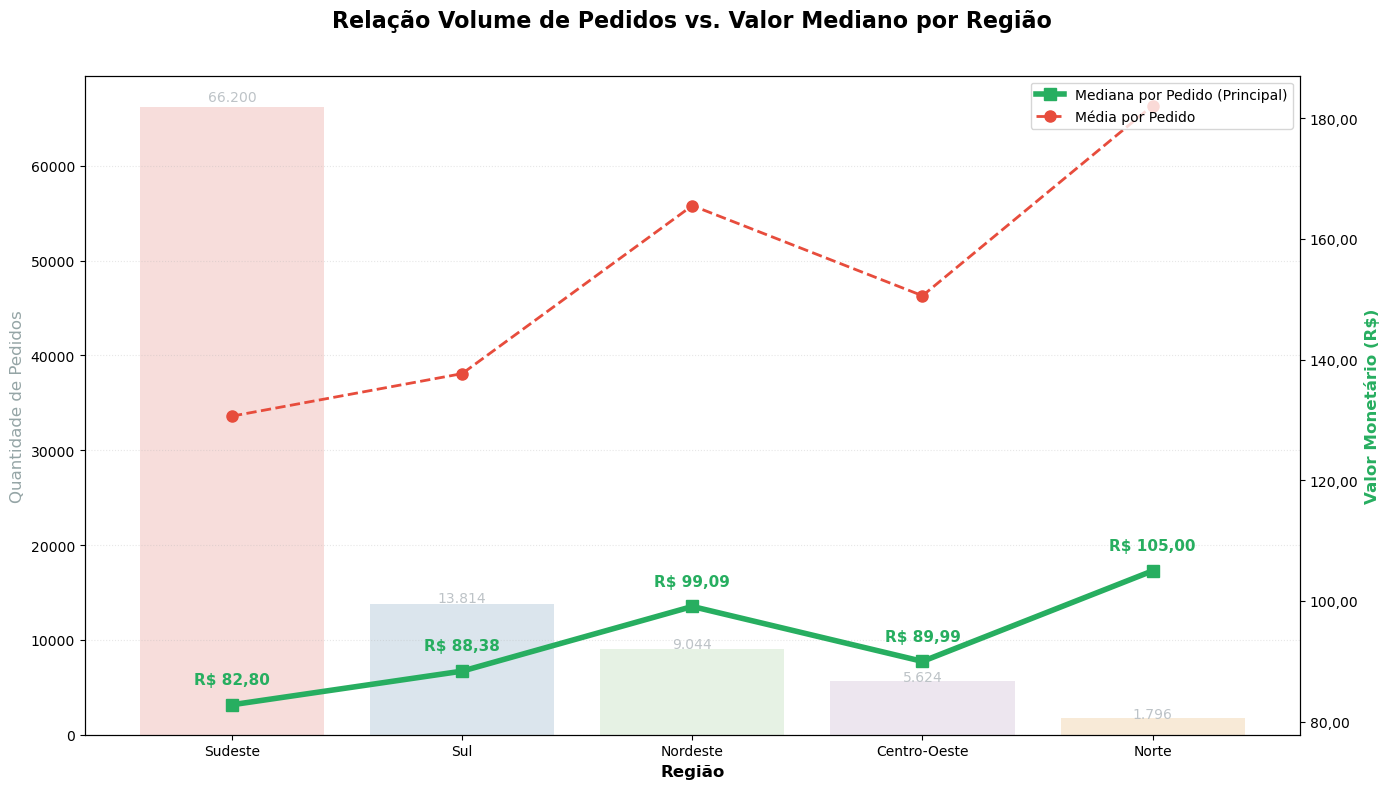

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

# 1. Preparação dos dados
resumo_regiao = pedidos_valor.groupby('regiao').agg(
    qtde_pedidos=('order_id', 'nunique'),
    media_valor=('valor_total', 'mean'),
    mediana_valor=('valor_total', 'median')
).sort_values('qtde_pedidos', ascending=False).reset_index()

# Função para formatar números no padrão brasileiro (1.000,00)
def formata_br(valor, pos=None):
    return f'{valor:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.')

def formata_int_br(valor):
    return f'{int(valor):,}'.replace(',', '.')

fig, ax1 = plt.subplots(figsize=(14, 8))

# --- Quantidade (Eixo Y Esquerdo - Barras Suaves) ---
# Cores bem claras para o fundo
sns.barplot(x='regiao', y='qtde_pedidos', data=resumo_regiao, 
            palette="Pastel1", hue='regiao', legend=False, ax=ax1, alpha=0.5)

ax1.set_ylabel("Quantidade de Pedidos", fontsize=12, color='#95a5a6')
ax1.set_xlabel("Região", fontsize=12, fontweight='bold')

# Rótulos de quantidade (Cinza claro, sem negrito)
for i, v in enumerate(resumo_regiao['qtde_pedidos']):
    ax1.text(i, v + (v * 0.01), formata_int_br(v), 
             ha='center', color='#bdc3c7', fontsize=10)

# --- Linha: Média e Mediana (Eixo Y Direito) ---
ax2 = ax1.twinx()

# Linha da MEDIANA (Destaque Principal - Verde)
ax2.plot(resumo_regiao['regiao'], resumo_regiao['mediana_valor'], 
         marker='s', markersize=8, color='#27ae60', linewidth=4, label='Mediana por Pedido (Principal)')

# Linha da MÉDIA (Secundária - Vermelha Tracejada)
ax2.plot(resumo_regiao['regiao'], resumo_regiao['media_valor'], 
         marker='o', markersize=8, color='#e74c3c', linewidth=2, linestyle='--', label='Média por Pedido')

ax2.set_ylabel("Valor Monetário (R$)", fontsize=12, fontweight='bold', color='#27ae60')

# Rótulos da Mediana (Negrito, Formato R$ 0,00)
for i, row in resumo_regiao.iterrows():
    valor_formatado = f"R$ {row['mediana_valor']:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.')
    ax2.annotate(valor_formatado, 
                 (i, row['mediana_valor']), 
                 textcoords="offset points", xytext=(0, 15), 
                 ha='center', color='#27ae60', fontweight='bold', fontsize=11)

# Ajustar eixo Y para formato de moeda BR
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(formata_br))

# Configuração final
plt.title("Relação Volume de Pedidos vs. Valor Mediano por Região", fontsize=16, pad=35, fontweight='bold')
ax1.grid(axis='y', linestyle=':', alpha=0.3)

# Legenda unificada
lines, labels = ax2.get_legend_handles_labels()
ax2.legend(lines, labels, loc='upper right', frameon=True)

plt.tight_layout()
plt.show()

#### **Análise do Volume vs. Ticket Médio por Região** 

Este gráfico utiliza um eixo duplo para comparar o volume absoluto de pedidos (barras) com o comportamento de gasto (linhas de média e mediana).

**1. Dominância Operacional do Sudeste:**  
A altura da barra confirma que a região Sudeste detém a vasta maioria da operação (mais de 66 mil pedidos). Isso indica a forte penetração logística e de mercado nessa região, que serve como o motor de volume do marketplace.

**2. Nordeste e Norte: O maior valor por pedido:** A região Nordeste apresenta a terceira maior quantidade de pedidos e ostenta o segundo maior ticket médio (mediana) de 99,00, ocupando a posição central do gráfico. Já o Norte, apesar do menor volume, possui a maior mediana entre as regiões (105,00). Isso mostra que, nessas localidades, que são próximas, o foco do consumo tende a ser em produtos de maior valor agregado.

**3. Sul e Centro-Oeste:** O Sul ocupa a segunda posição em volume (13.814 pedidos), com uma mediana de 88,38. O Centro-Oeste apresenta comportamento intermediário, com mediana de 89,99. Ambas as regiões mostram uma homogeneidade no perfil de consumo em relação ao Sudeste, talvez também relacionadas a proximade com essa região de destaque. 

**4. Mediana vs. Média Aritmética:** No gráfico, é possível visualizar que a Mediana se mostra muito mais estável entre as regiões do que a Média. Enquanto a Média (linha vermelha tracejada) é "puxada" para cima por possiveis valores extremos (outliers), a Mediana revela que o gasto típico do cliente é equilibrado, variando entre 82,80 e 105,00.

**5. Conclusão:** Fica evidente uma relação inversa nas regiões onde o volume de vendas é menor (Norte, Nordeste e Centro-Oeste), o valor gasto por pedido tende a ser maior. Isso reforça a tese de que, em regiões onde o acesso é mais fácil e o frete é mais barato (Sudeste e Sul), os clientes realizam compras menores e mais frequentes. Já onde o frete é possivelmente mais oneroso, os clientes tendem a realizar pedidos de maior valor para compensar os custos de envio.  
Em relação ao volume ser muito maior na regiões Sudeste e Sul, isso pode estar relacionado com a renda per capita dessas regiões ser média muito maior que das outras regiões do pais, logo, esse fato também se relaciona diretamente com o acessos e hábitos de consumo por plataformas de  digitais, como a base de dados analisada é do período entre 2016 e 2018, essas diferenças regionais poderiam ser ainda maiores do que são hoje.

In [9]:
import plotly.express as px

# Agrupando a mediana do frete por região
frete_regiao = dataset.groupby('regiao')['freight_value'].median().reset_index().sort_values(by='freight_value')

fig_frete = px.bar(
    frete_regiao, 
    x='regiao', 
    y='freight_value',
    title="<b>Mediana do Valor do Frete por Região</b>",
    labels={'freight_value': 'Valor do Frete (R$)', 'regiao': 'Região'},
    text_auto='.2f',
    color='freight_value',
    color_continuous_scale='Reds'
)

fig_frete.update_layout(separators=',.')
fig_frete.show()

#### **Valor do Frete por Região:**  
O gráfico mostra uma diferença significativa entre os valores médios (mediana) dos fretes entre a região Sudeste (15,10) e Norte (29,10), regiões de maior e menor volume de pedidos respectivamente. Essa diferença de custo é praticamente o dobro.  
Isso confirma a análise anterior, onde o valor do frete é apontado como um dos fatores determinantes tanto para o maior volume de pedidos nas regiões Sul e Sudeste, quanto para o ticket médio mais elevado nas regiões Norte, Nordeste e Centro-Oeste.


#### **Mapa: Faturamento por Estado** 
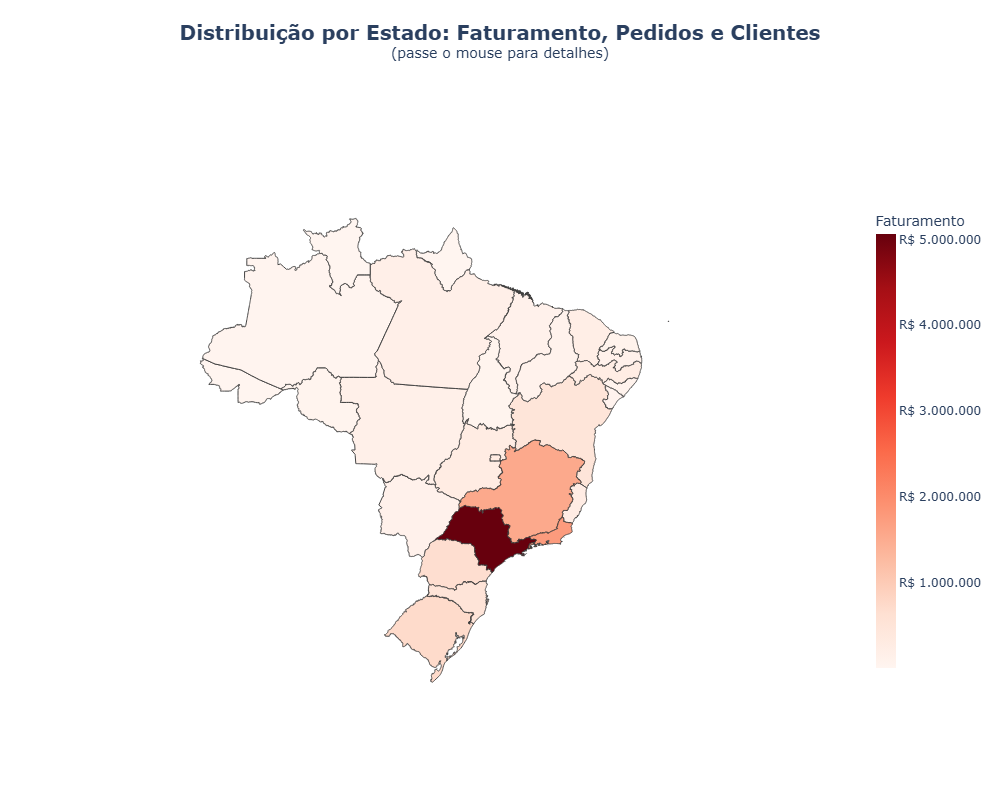

>###### **OBS: Adicionei a imagem fixa para sair no pdf, mapa interativo na próxima celula.** 

In [10]:
# Mapa de Faturamento por Região (faturamento, qtde de pedidos e qtde de clientes)

import plotly.express as px

# 1. Agrupar os dados usando 
resumo_estados = dataset.groupby('customer_state').agg({
    'price': 'sum',
    'order_id': 'nunique',
    'customer_unique_id': 'nunique'
}).reset_index()

resumo_estados.columns = ['UF', 'Faturamento', 'Pedidos', 'Clientes']

# 2. Criar o mapa
geojson_br = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson"

fig = px.choropleth(
    resumo_estados, 
    geojson=geojson_br,
    locations='UF', 
    featureidkey="properties.sigla",
    color='Faturamento',
    hover_name='UF',
    # Customizando a exibição dos dados
    hover_data={
        'UF': False,
        'Faturamento': ':,.2f', 
        'Pedidos': ':,', 
        'Clientes': ':,'
    },
    color_continuous_scale="Reds",
    scope='south america',
    height=800,
    width=1000 
)

# --- configuração 
fig.update_layout(
    separators=',.', # Define vírgula para decimal e ponto para milhar
    title={
        'text': "<b>Distribuição por Estado: Faturamento, Pedidos e Clientes</b><br><sup>(passe o mouse para detalhes)</sup>",
        'y':0.95,
        'x':0.5,
        'xanchor': 'center',
        'yanchor': 'top',
        'font': {'size': 20}
    },
    margin={"r":20,"t":100,"l":20,"b":20},
    coloraxis_colorbar=dict(
        title="Faturamento",
        tickprefix="R$ ",
        thickness=20,
        len=0.7,
        # Formata os números da barra lateral também
        tickformat=",", 
    )
)

fig.update_geos(
    fitbounds="locations", 
    visible=False,
    projection_type="mercator"
)

fig.show()